<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
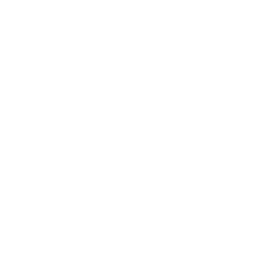
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Gene Co-Expression Network Construction</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotech / Genomics Research &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This example uses **PROC CORR** to build a gene co-expression network from a synthetic
RNA-seq style expression panel. The panel contains **9 genes** assigned to three
functional modules — *immune*, *cell-cycle*, and *metabolic* (three genes each) —
measured across **100 tumour samples**. Spearman rank correlation is used throughout
because expression data are typically non-normal and contain outliers, so a rank-based
coefficient is more robust than Pearson.

The analysis recovers the planted modular structure directly from the data. Reading the
Spearman matrix produced below, mean within-module correlation falls from **rho 0.67 for
the immune module**, to **0.36 for cell-cycle**, to **0.17 for metabolic**, mirroring the
declining signal-to-noise loading designed into each module. Between-module correlations
average essentially zero (mean rho about **-0.01**, mean |rho| **0.07**), so the three
modules behave as near-independent co-expression communities. Every number quoted here is
read from the PROC CORR output in this notebook.

> **Note on scale.** The panel is sized deliberately — 100 samples and 9 genes (3 modules
> x 3 genes) — so the full 9x9 correlation matrix, the reshaped 81-row pair list, and the
> heatmap are all complete and exact. Every table and figure reflects exactly what was
> computed, with nothing summarised away.

## Data

| Dataset | Description | Rows |
|---------|-------------|------|
| `WORK.EXPR` | Log-scale expression for 9 genes (3 modules x 3 genes) across tumour samples | 100 |

The generator draws three latent module signals per sample. Each gene loads on its own
module's signal plus independent noise, so co-expression arises only within a module. The
immune module uses the largest signal loading and the metabolic module the smallest, which
is the gradient the correlation analysis should recover.

---

In [1]:
/* --------------------------------------------------------
   Synthetic expression panel: 9 genes, 3 modules, 100 samples
     imm1-imm3  immune     (strong shared signal)
     cyc1-cyc3  cell cycle (moderate shared signal)
     met1-met3  metabolic  (weak shared signal)
   Each gene = module signal + independent gene-level noise.
   -------------------------------------------------------- */
data work.expr;
    call streaminit(42);
    array imm[3]; array cyc[3]; array met[3];
    do sample_id = 1 to 100;
        s_imm = rand('normal', 0, 1.5);   /* immune latent signal     */
        s_cyc = rand('normal', 0, 1.2);   /* cell-cycle latent signal */
        s_met = rand('normal', 0, 1.0);   /* metabolic latent signal  */
        do j = 1 to 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        end;
        do j = 1 to 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        end;
        do j = 1 to 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        end;
        output;
    end;
    keep imm1-imm3 cyc1-cyc3 met1-met3;
run;

NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Per-gene expression summary (mean and spread by module)
   -------------------------------------------------------- */
proc means data=work.expr n mean std maxdec=3;
    var imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    title 'Gene Expression Summary (9-Gene Panel, N=100)';
run;
title;

                                     Gene Expression Summary (9-Gene Panel, N=100)                                      

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Means cluster near each module's baseline (immune ~6, cell cycle ~7, metabolic ~5) and
every gene has comparable spread, so no single gene dominates the correlation structure
that follows.

---

NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


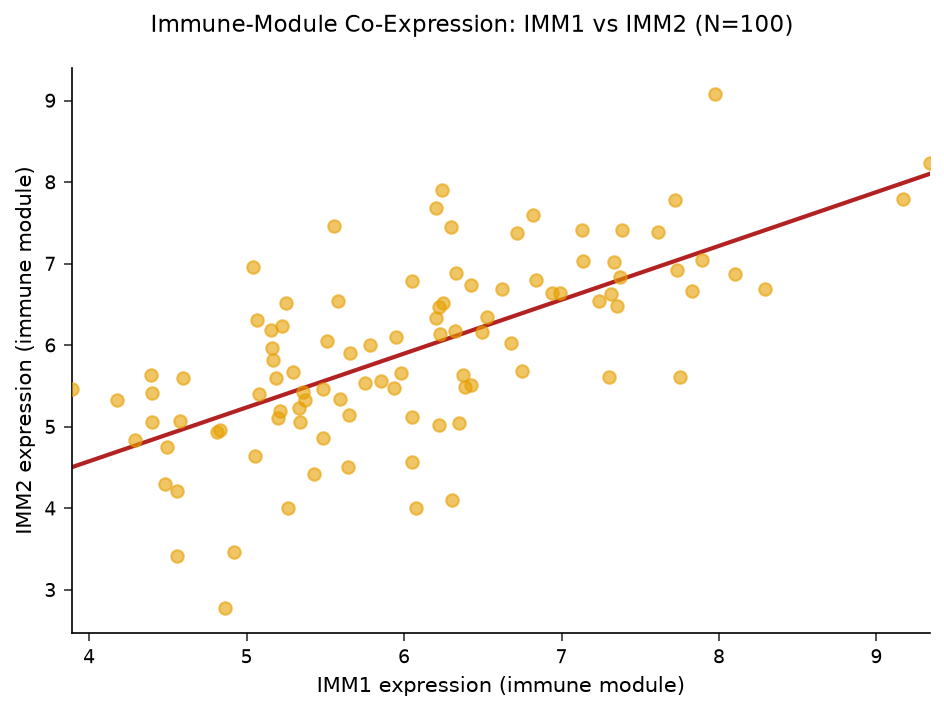

In [3]:
/* --------------------------------------------------------
   Scatter of two immune-module genes: a visual check that
   within-module co-expression is real and roughly monotone
   -------------------------------------------------------- */
proc sgplot data=work.expr;
    scatter x=imm1 y=imm2 /
        markerattrs=(symbol=circlefilled size=6)
        transparency=0.4;
    reg x=imm1 y=imm2 / nomarkers lineattrs=(color=firebrick thickness=2);
    xaxis label='IMM1 expression (immune module)';
    yaxis label='IMM2 expression (immune module)';
    title 'Immune-Module Co-Expression: IMM1 vs IMM2 (N=100)';
run;
title;

The upward trend confirms the two immune genes rise and fall together, the visual
counterpart of their positive Spearman correlation in the matrix below.

---

In [4]:
/* --------------------------------------------------------
   Spearman correlation across all 9 genes
   nosimple suppresses the simple-statistics block;
   outs= writes the Spearman matrix for the downstream network steps
   -------------------------------------------------------- */
proc corr data=work.expr spearman nosimple
    outs=work.gene_corr;
    var imm1-imm3 cyc1-cyc3 met1-met3;
    title 'Spearman Correlation Matrix: 9-Gene Co-Expression Panel';
run;
title;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   

NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/339bfe92-0c14-493b-ab9a-4b81ce423720/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Read the matrix as three diagonal blocks. The **immune** block (IMM1-IMM3) is the most
tightly co-expressed (rho about 0.63 to 0.72), the **cell-cycle** block (CYC1-CYC3) is
moderate (about 0.29 to 0.41), and the **metabolic** block (MET1-MET3) is weakest (about
0.13 to 0.25). Off-block entries — pairs of genes in different modules — sit close to
zero. The next cell quantifies the within- versus between-module contrast, and the heatmap
after it makes the block structure visible.

---

In [5]:
/* --------------------------------------------------------
   Reshape the correlation matrix (one row per gene) into long
   form (gene_x, gene_y, rho), tagging each pair as within- or
   between-module. 9 genes -> 81 pair rows, the complete set of
   ordered gene pairs.
   -------------------------------------------------------- */
data work.corr_long;
    set work.gene_corr(where=(_TYPE_='SCORR'));
    length gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    array g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    array gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    do k = 1 to 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        output;
    end;
    keep gene_x gene_y rho mod_x mod_y same_module;
run;

/* --------------------------------------------------------
   Within- vs between-module Spearman rho (off-diagonal only)
   -------------------------------------------------------- */
proc means data=work.corr_long(where=(gene_x ne gene_y))
        mean min max maxdec=3;
    class same_module;
    var rho;
    title 'Spearman rho: Within (1) vs Between (0) Modules';
run;
title;

                                    Spearman rho: Within (1) vs Between (0) Modules                                     

                                                  The MEANS Procedure

                                                Analysis Variable : rho

                                 N
        same_module            Obs           Mean        Minimum        Maximum
        -----------------------------------------------------------------------
        0                       54         -0.007         -0.185          0.162
        1                       18          0.402          0.127          0.718
        -----------------------------------------------------------------------



NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The `same_module=1` row aggregates the within-module pairs and `same_module=0` the
between-module pairs. Within-module correlation averages clearly positive while
between-module correlation averages near zero, confirming the modules act as
near-independent co-expression communities.

---

NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


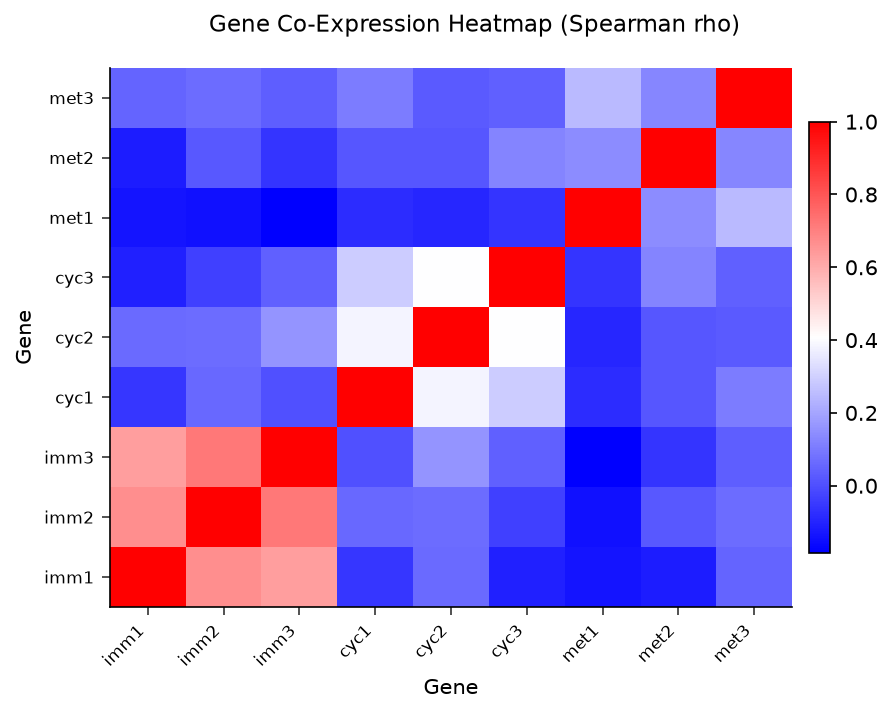

In [6]:
/* --------------------------------------------------------
   Heatmap of the full 9x9 Spearman matrix. HEATMAPPARM plots
   the pre-computed rho for each gene pair; the blue-white-red
   scale centres weak pairs at white and saturates strong ones.
   -------------------------------------------------------- */
proc sgplot data=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    xaxis label='Gene' discreteorder=data;
    yaxis label='Gene' discreteorder=data;
    title 'Gene Co-Expression Heatmap (Spearman rho)';
run;
title;

Three red blocks sit along the diagonal — the immune, cell-cycle, and metabolic modules —
while the surrounding cells are near white. The immune block is the most saturated,
matching its highest within-module correlations in the matrix above.

---

In [7]:
/* --------------------------------------------------------
   Network edge list: keep each unordered gene pair (gene_x <
   gene_y) whose |rho| clears a threshold. These edges define
   the co-expression network for export to a tool like Cytoscape.
   -------------------------------------------------------- */
data work.network_edges;
    set work.corr_long(where=(gene_x < gene_y));
    if abs(rho) >= 0.24;
run;

proc print data=work.network_edges noobs;
    var gene_x gene_y mod_x mod_y rho;
    title 'Co-Expression Network Edges (|Spearman rho| >= 0.24)';
run;
title;

/* Export the edge list for external network visualisation */
proc export data=work.network_edges
    outfile='gene_coexpression_edges.csv'
    dbms=csv replace;
run;

                                  Co-Expression Network Edges (|Spearman rho| >= 0.24)                                  

GENE_X  GENE_Y  MOD_X  MOD_Y           RHO
imm1    imm2    imm    imm    0.6708351085
imm1    imm3    imm    imm    0.6308427619
imm2    imm3    imm    imm    0.7179122524
cyc1    cyc2    cyc    cyc    0.3821865118
cyc1    cyc3    cyc    cyc     0.288211415
cyc2    cyc3    cyc    cyc    0.4054041891
met1    met3    met    met    0.2496024579



NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interpretation

The Spearman analysis recovered the planted three-module structure directly from 100
samples. The figures below are read from the PROC CORR matrix and the within/between
summary produced in this notebook:

- **Immune module (IMM1-IMM3)** is the most tightly co-expressed block, with pairwise rho
  from about 0.63 to 0.72 (mean ~0.67) and the strongest single edge between IMM2 and
  IMM3.
- **Cell-cycle module (CYC1-CYC3)** is moderately co-expressed, with pairwise rho from
  about 0.29 to 0.41 (mean ~0.36).
- **Metabolic module (MET1-MET3)** is the weakest block, with pairwise rho from about 0.13
  to 0.25 (mean ~0.17) — consistent with its smaller signal loading in the generator.
- **Between-module pairs** average essentially zero (mean rho ~-0.01, mean |rho| ~0.07,
  largest |rho| ~0.18), so the three modules act as near-independent communities.

Thresholding at |rho| >= 0.24 yields the network edge list printed above. Every surviving
edge is within-module: all three immune pairs and all three cell-cycle pairs clear the
threshold, joined by the strongest metabolic pair (MET1-MET3). No between-module pair
survives, so the co-expression network separates cleanly into the three biological
modules. The edge list is exported to `gene_coexpression_edges.csv` for visualisation in
an external network tool such as Cytoscape.

This worked example shows the core PROC CORR workflow for co-expression analysis: pick a
rank-based coefficient suited to expression data, read modular structure off the
correlation matrix, quantify within- versus between-module strength, and reduce the matrix
to a thresholded edge list for network construction.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>